# 6CS012 – Final Portfolio Assessment 2026
## Part III: Natural Language Processing Task
## Sentiment Analysis of Financial News using RNN, LSTM, and Word2Vec

**Student Name:** Snigdha Shrestha  
**Student ID:** 2431158  
**Module:** Artificial Intelligence and Machine Learning (6CS012)  



Section 1: Install and Import Libraries

In [1]:
!pip install nltk gensim wordcloud --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.5 MB/s eta 0:00:00


In [2]:
# ── Core Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
import os

warnings.filterwarnings('ignore')

# ── NLP Libraries ───────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Download required NLTK data
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',     quiet=True)

# ── Sklearn ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# ── Keras / TensorFlow ───────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from keras.models import Sequential
from keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense,
    Dropout, BatchNormalization
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

# ── Gensim (Word2Vec) ────────────────────────────────────────────
import gensim.downloader as gensim_api

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Keras version      : {keras.__version__}")

✅ All libraries imported successfully!
   TensorFlow version : 2.20.0
   Keras version      : 3.13.2


Section 2: Load and explore the dataset

In [3]:
DATA_PATH ='/content/drive/MyDrive/Collection of Dataset for Text Classification/3. Financial Phrase Dataset/financial_phrase.csv'

df = pd.read_csv(DATA_PATH)
print("=" * 55)
print(" DATASET OVERVIEW")
print("=" * 55)
print(f" Total Samples  : {len(df)}")
print(f" Total Columns  : {df.shape[1]}")
print(f" Missing Values : {df.isnull().sum().sum()}")
print("=" * 55)
df.head(10)

 DATASET OVERVIEW
 Total Samples  : 2264
 Total Columns  : 2
 Missing Values : 0


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive
5,Finnish Talentum reports its operating profit ...,positive
6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,positive
7,Consolidated net sales increased 16 % to reach...,positive
8,Foundries division reports its sales increased...,positive
9,"HELSINKI ( AFX ) - Shares closed higher , led ...",positive


Label Distribution:
------------------------------
  neutral   : 1391  (61.4%)
  positive  :  570  (25.2%)
  negative  :  303  (13.4%)


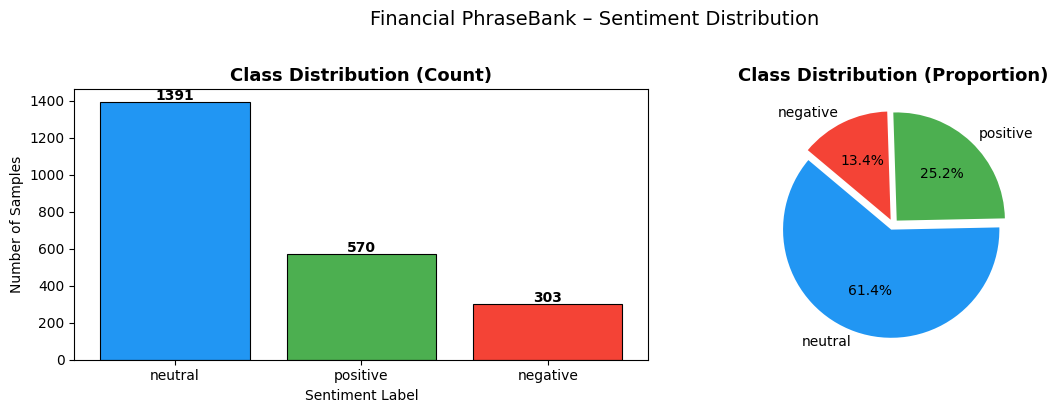


  Note: Dataset is imbalanced — 'neutral' class dominates at 61.5%.
   This will be factored into model evaluation using per-class metrics.


In [4]:
# ── Class Distribution ──────────────────────────────────────────
print("Label Distribution:")
print("-" * 30)
label_counts = df['label'].value_counts()
label_pct    = df['label'].value_counts(normalize=True) * 100

for label in label_counts.index:
    print(f"  {label:<10}: {label_counts[label]:>4}  ({label_pct[label]:.1f}%)")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2196F3', '#4CAF50', '#F44336']

# Bar chart
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05, 0.05, 0.05]
)
axes[1].set_title('Class Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.suptitle('Financial PhraseBank – Sentiment Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Note: Dataset is imbalanced — 'neutral' class dominates at 61.5%.")
print("   This will be factored into model evaluation using per-class metrics.")

Text Length Statistics (word count):
----------------------------------------
           count  mean   std  min   25%   50%   75%   max
label                                                    
negative   303.0  24.8  10.3  5.0  17.0  22.0  30.0  56.0
neutral   1391.0  20.9   9.7  2.0  14.0  19.0  26.0  81.0
positive   570.0  24.9  10.5  6.0  17.0  23.0  31.0  57.0


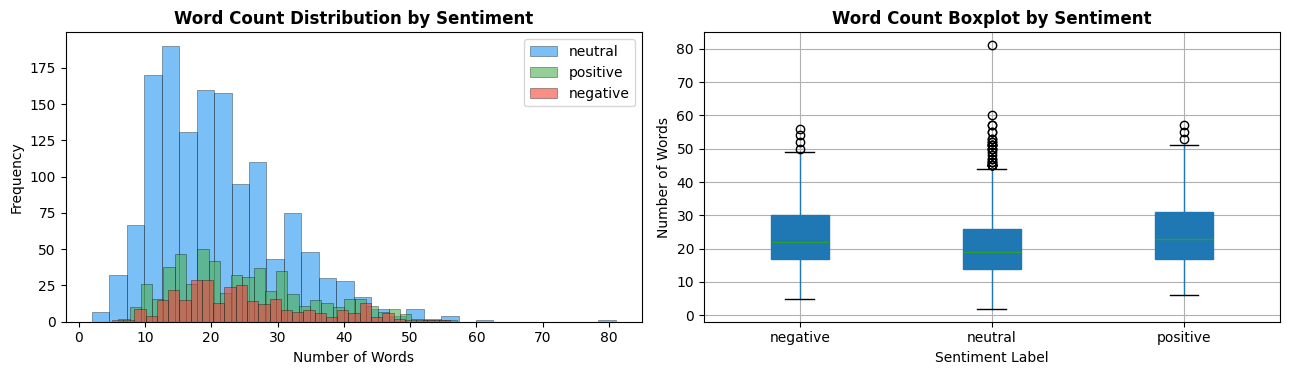

In [5]:
# ── Text Length Analysis ────────────────────────────────────────
df['text_length']  = df['text'].apply(lambda x: len(x.split()))
df['char_length']  = df['text'].apply(len)

print("Text Length Statistics (word count):")
print("-" * 40)
print(df.groupby('label')['text_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip(df['label'].unique(), colors):
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.4)

axes[0].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

df.boxplot(column='text_length', by='label', ax=axes[1], patch_artist=True)
axes[1].set_title('Word Count Boxplot by Sentiment', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Number of Words')
plt.suptitle('')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Section 3: Text Preprocessing and Cleaning

In [6]:
# ── Contraction Dictionary ───────────────────────────────────────
CONTRACTIONS = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot",
    "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will",
    "he's": "he is", "i'd": "i would", "i'll": "i will",
    "i'm": "i am", "i've": "i have", "isn't": "is not",
    "it's": "it is", "let's": "let us", "mightn't": "might not",
    "mustn't": "must not", "shan't": "shall not", "she'd": "she would",
    "she'll": "she will", "she's": "she is", "shouldn't": "should not",
    "that's": "that is", "there's": "there is", "they'd": "they would",
    "they'll": "they will", "they're": "they are", "they've": "they have",
    "wasn't": "was not", "we'd": "we would", "we're": "we are",
    "we've": "we have", "weren't": "were not", "what's": "what is",
    "where's": "where is", "who's": "who is", "won't": "will not",
    "wouldn't": "would not", "you'd": "you would", "you'll": "you will",
    "you're": "you are", "you've": "you have"
}

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep some financial negation words that matter for sentiment
# (removing 'not', 'no' would lose important negative signal)
KEEP_WORDS = {'not', 'no', 'nor', 'neither', 'never', 'up', 'down'}
stop_words -= KEEP_WORDS


def expand_contractions(text):
    """Replace contractions with their full forms."""
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
    return text


def clean_text(text):
    """
    Full cleaning pipeline:
      1. Lowercase
      2. Expand contractions
      3. Remove URLs, mentions, hashtags
      4. Remove numbers and special characters
      5. Remove extra whitespace
      6. Remove stopwords
      7. Lemmatize
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions
    text = expand_contractions(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 4. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove numbers and special characters (keep letters and spaces only)
    text = re.sub(r'[^a-z\s]', '', text)

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenize, remove stopwords, and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 1
    ]

    return ' '.join(tokens)


# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)

# Preview before vs after
print("Cleaning Preview (first 3 samples):")
print("=" * 70)
for i in range(3):
    print(f"[{df['label'].iloc[i].upper()}]")
    print(f"  BEFORE: {df['text'].iloc[i][:120]}...")
    print(f"  AFTER : {df['cleaned_text'].iloc[i][:120]}...")
    print("-" * 70)

# Check for any empty strings after cleaning
empty_after_clean = (df['cleaned_text'].str.strip() == '').sum()
print(f"\nEmpty strings after cleaning: {empty_after_clean}")
if empty_after_clean > 0:
    df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
    print(f"  Removed {empty_after_clean} empty rows. New size: {len(df)}")

Cleaning Preview (first 3 samples):
[NEUTRAL]
  BEFORE: According to Gran , the company has no plans to move all production to Russia , although that is where the company is gr...
  AFTER : according gran company no plan move production russia although company growing...
----------------------------------------------------------------------
[POSITIVE]
  BEFORE: For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier...
  AFTER : last quarter componenta net sale doubled eurm eurm period year earlier moved zero pretax profit pretax loss eurm...
----------------------------------------------------------------------
[POSITIVE]
  BEFORE: In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5...
  AFTER : third quarter net sale increased eur mn operating profit eur mn...
----------------------------------------------------------------------

Empty strings after c

Section 4: Data visualization

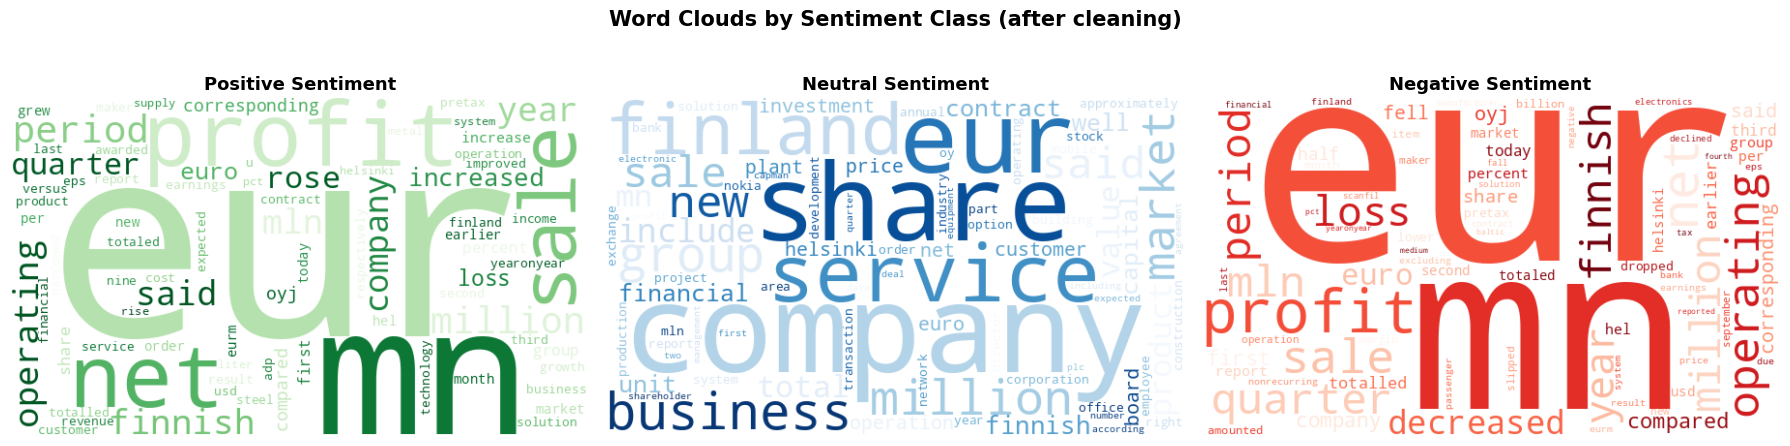

In [7]:
# ── Word Cloud per Sentiment Class ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colormap_map = {
    'positive': 'Greens',
    'neutral' : 'Blues',
    'negative': 'Reds'
}

for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    text_corpus = ' '.join(df[df['label'] == label]['cleaned_text'])
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap_map[label],
        max_words=80,
        collocations=False
    ).generate(text_corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.capitalize()} Sentiment', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class (after cleaning)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

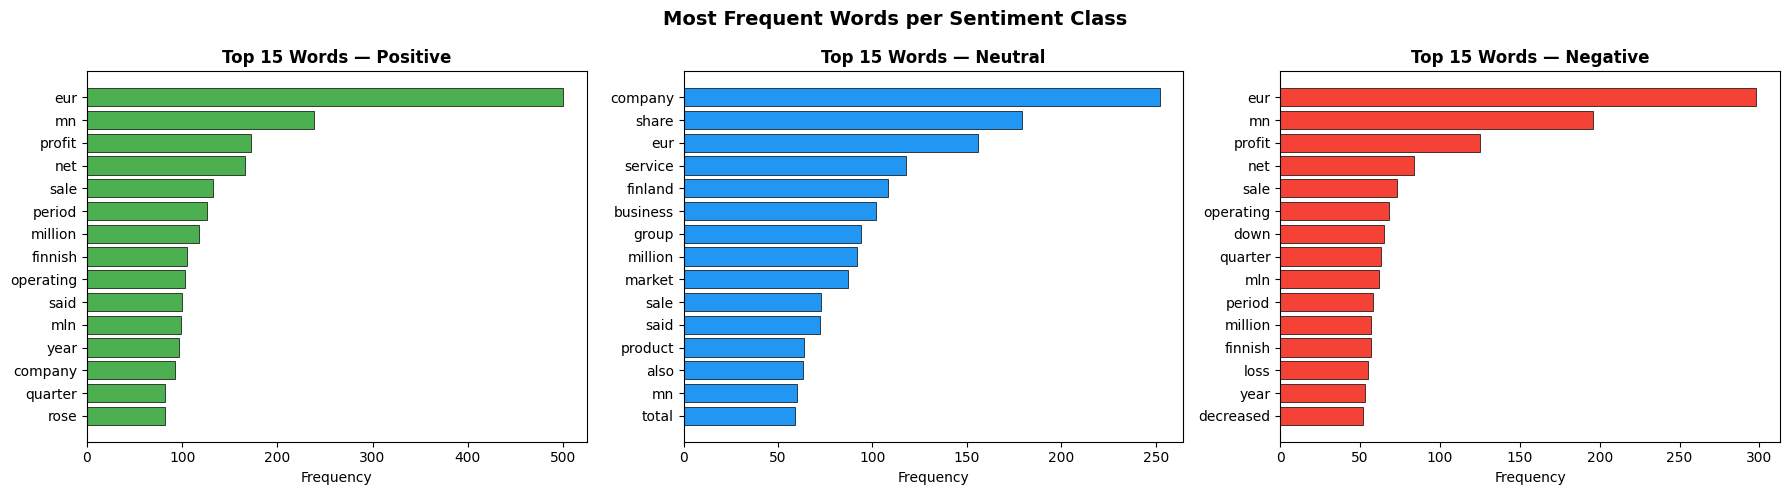

In [8]:
# ── Top 15 Most Frequent Words per Class ────────────────────────
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = {'positive': '#4CAF50', 'neutral': '#2196F3', 'negative': '#F44336'}

for ax, label in zip(axes, ['positive', 'neutral', 'negative']):
    all_words = ' '.join(df[df['label'] == label]['cleaned_text']).split()
    top_words = Counter(all_words).most_common(15)
    words, counts = zip(*top_words)

    ax.barh(words[::-1], counts[::-1], color=bar_colors[label], edgecolor='black', linewidth=0.5)
    ax.set_title(f'Top 15 Words — {label.capitalize()}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Sentiment Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

Section 5 : Label encoding, tokenization and sequence padding

In [9]:
# ── Label Encoding ───────────────────────────────────────────────
# Map sentiment labels to integers
label_map     = {'negative': 0, 'neutral': 1, 'positive': 2}
inv_label_map = {v: k for k, v in label_map.items()}

df['label_encoded'] = df['label'].map(label_map)
NUM_CLASSES = 3

print("Label encoding:")
for k, v in label_map.items():
    print(f"  {k:>10} → {v}")

# ── Train / Validation / Test Split ─────────────────────────────
# Split: 80% train, 10% val, 10% test
X = df['cleaned_text'].values
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nDataset Split:")
print(f"  Train      : {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Validation : {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"  Test       : {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

Label encoding:
    negative → 0
     neutral → 1
    positive → 2

Dataset Split:
  Train      : 1811 samples (80.0%)
  Validation : 226 samples (10.0%)
  Test       : 227 samples (10.0%)


In [10]:
# ── Tokenization ─────────────────────────────────────────────────
# Fit tokenizer on training data only (avoid data leakage)
MAX_VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE  = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
word_index  = tokenizer.word_index

print(f"Total unique words in training data : {len(tokenizer.word_index)}")
print(f"Vocabulary size used                : {VOCAB_SIZE}")

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print(f"\nSample sequence (first train item):")
print(f"  Text     : {X_train[0][:80]}")
print(f"  Sequence : {X_train_seq[0]}")

Total unique words in training data : 4402
Vocabulary size used                : 4403

Sample sequence (first train item):
  Text     : merrill lynch analyst campbell morgan upgraded recommendation paperlinx neutral 
  Sequence : [1362, 1363, 358, 2027, 849, 850, 616, 2028, 1364, 524, 148]


In [11]:
# ── Percentile-based Padding Length ─────────────────────────────
# Use 90th percentile to avoid excessively long sequences
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN     = int(np.percentile(seq_lengths, 90))

print(f"Sequence length statistics (training set):")
print(f"  Mean   : {np.mean(seq_lengths):.1f}")
print(f"  Median : {np.median(seq_lengths):.1f}")
print(f"  90th % : {np.percentile(seq_lengths, 90):.1f}  ← MAX_LEN chosen here")
print(f"  Max    : {np.max(seq_lengths)}")
print(f"\nMAX_LEN set to: {MAX_LEN}")

# Apply padding (post-padding, post-truncating)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nPadded shapes:")
print(f"  X_train_pad : {X_train_pad.shape}")
print(f"  X_val_pad   : {X_val_pad.shape}")
print(f"  X_test_pad  : {X_test_pad.shape}")

# One-hot encode labels for categorical crossentropy
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"\nLabel shapes:")
print(f"  y_train_cat : {y_train_cat.shape}")

Sequence length statistics (training set):
  Mean   : 11.5
  Median : 10.0
  90th % : 20.0  ← MAX_LEN chosen here
  Max    : 36

MAX_LEN set to: 20

Padded shapes:
  X_train_pad : (1811, 20)
  X_val_pad   : (226, 20)
  X_test_pad  : (227, 20)

Label shapes:
  y_train_cat : (1811, 3)


Section 6 : Model 1- Simple RNN with trainable embedding

In [29]:
# ── Hyperparameters ──────────────────────────────────────────────
EMBEDDING_DIM = 64
BATCH_SIZE    = 32
EPOCHS        = 30

# ── Build Simple RNN Model ───────────────────────────────────────
def build_rnn_model(vocab_size, embedding_dim, max_len, num_classes):
    model = Sequential(name='SimpleRNN_Model')

    # Embedding layer — learns word representations from scratch
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding'
    ))

    # SimpleRNN layer
    model.add(SimpleRNN(64, return_sequences=False, name='simple_rnn'))
    model.add(Dropout(0.4, name='dropout_1'))

    # Dense hidden layer
    model.add(Dense(32, activation='relu', name='dense_1'))
    model.add(Dropout(0.3, name='dropout_2'))

    # Output layer — softmax for 3-class classification
    model.add(Dense(num_classes, activation='softmax', name='output'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_rnn = build_rnn_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN, NUM_CLASSES)
model_rnn.build(input_shape=(None, MAX_LEN))
model_rnn.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       281,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,227 (1.11 MB)

 Trainable params: 292,227 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── Callbacks ────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

# ── Train Model 1 ────────────────────────────────────────────────
print("Training Model 1: Simple RNN...")
history_rnn = model_rnn.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Training Model 1: Simple RNN...
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.6378 - loss: 0.8691 - val_accuracy: 0.7212 - val_loss: 0.6355 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7819 - loss: 0.5101 - val_accuracy: 0.7611 - val_loss: 0.5507 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8515 - loss: 0.3254 - val_accuracy: 0.7876 - val_loss: 0.5282 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9348 - loss: 0.1831 - val_accuracy: 0.7920 - val_loss: 0.6338 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9564 - loss: 0.1269 - val_accuracy: 0.8274 - val_loss: 0.6102 - learning_rate: 0.0010
Epoch 6/30
54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9729 - loss: 0.0831
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 

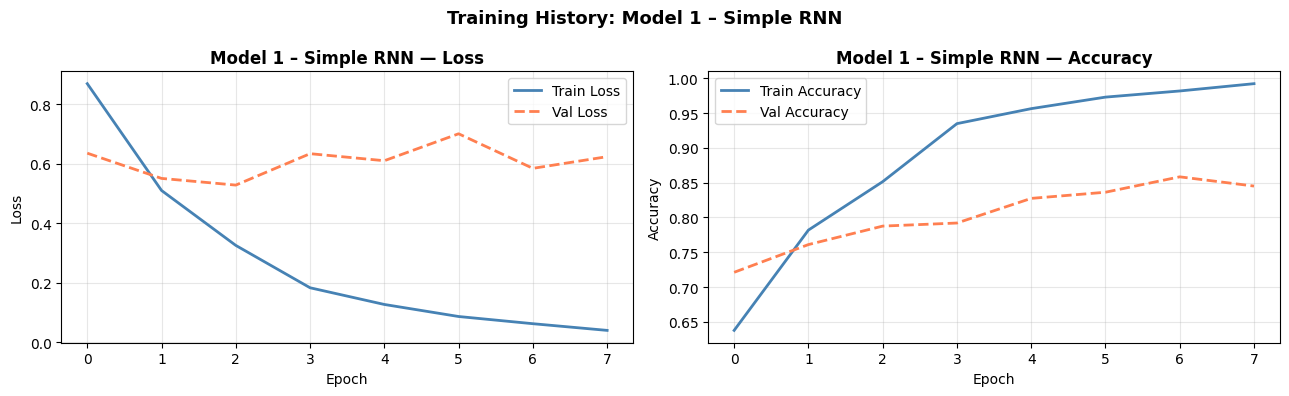

In [14]:
# ── Plot Training Curves ─────────────────────────────────────────
def plot_history(history, model_name, color='steelblue'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',      color=color,  linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',        color='coral', linewidth=2, linestyle='--')
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color=color,  linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='coral', linewidth=2, linestyle='--')
    axes[1].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f'Training History: {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_rnn, 'Model 1 – Simple RNN', color='steelblue')

Section 7: Model 2- LSTM with trainable embedding

In [31]:
# ── Build LSTM Model ─────────────────────────────────────────────
def build_lstm_model(vocab_size, embedding_dim, max_len, num_classes):
    model = Sequential(name='LSTM_Model')

    # Trainable embedding layer
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name='embedding'
    ))

    # LSTM layer — handles long-range dependencies better than SimpleRNN
    model.add(LSTM(128, return_sequences=True, name='lstm_1'))
    model.add(Dropout(0.4, name='dropout_1'))

    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(Dropout(0.3, name='dropout_2'))

    # Dense layers
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(Dropout(0.3, name='dropout_3'))

    # Output
    model.add(Dense(num_classes, activation='softmax', name='output'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_lstm = build_lstm_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LEN, NUM_CLASSES)
model_lstm.build(input_shape=(None, MAX_LEN))
model_lstm.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       281,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 434,371 (1.66 MB)

 Trainable params: 434,371 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

Training Model 2: LSTM...
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.6394 - loss: 0.8476 - val_accuracy: 0.7611 - val_loss: 0.6093 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7841 - loss: 0.5030 - val_accuracy: 0.7788 - val_loss: 0.5588 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.8305 - loss: 0.3683 - val_accuracy: 0.7743 - val_loss: 0.5908 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8531 - loss: 0.3119 - val_accuracy: 0.7389 - val_loss: 0.6821 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.8581 - loss: 0.3062 - val_accuracy: 0.7832 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8686 - loss: 0.2550 - val_accuracy: 0.8097 - val_loss: 0.5986 - learning_rate: 0.0010
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.882

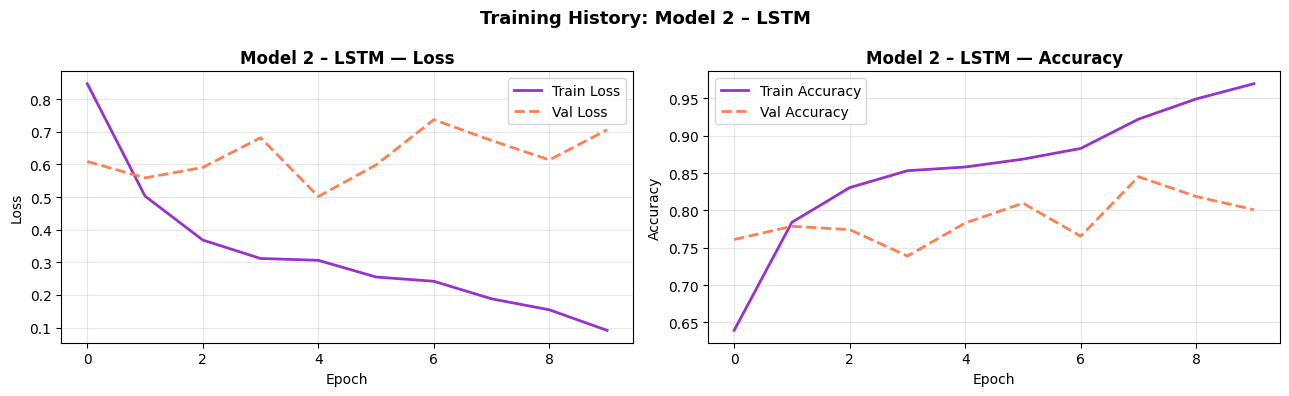

In [32]:
# ── Train Model 2 ────────────────────────────────────────────────
early_stop2 = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

print("Training Model 2: LSTM...")
history_lstm = model_lstm.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

plot_history(history_lstm, 'Model 2 – LSTM', color='darkorchid')

Section 8: Model 3- LSTM with pretrained Word2Vec (GLoVE) embedding

In [17]:
# ── Load Pretrained GloVe Embeddings via Gensim ──────────────────
# This will download ~66MB — takes a few minutes on first run
print("Loading GloVe embeddings (glove-wiki-gigaword-50)...")
print("This may take a few minutes on first download.")

glove_model = gensim_api.load('glove-wiki-gigaword-50')
W2V_DIM     = 50  # Must match the model chosen above

print(f"\n✅ GloVe loaded! Vocabulary size: {len(glove_model)}")
print(f"   Embedding dimension: {W2V_DIM}")

# Example: check a financial word
if 'profit' in glove_model:
    print(f"\n   Sample — 'profit' vector (first 5 dims): {glove_model['profit'][:5]}")

Loading GloVe embeddings (glove-wiki-gigaword-50)...
This may take a few minutes on first download.
[==================================================] 100.0% 66.0/66.0MB downloaded

✅ GloVe loaded! Vocabulary size: 400000
   Embedding dimension: 50

   Sample — 'profit' vector (first 5 dims): [ 0.44504   -0.83999    1.251      0.0077679  0.41529  ]


In [18]:
# ── Build Embedding Matrix ───────────────────────────────────────
# Map each word in our vocabulary to its GloVe vector
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
covered_words    = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        covered_words += 1
    # Words not found remain as zero vectors

coverage = (covered_words / min(len(word_index), VOCAB_SIZE)) * 100
print(f"Embedding matrix shape  : {embedding_matrix.shape}")
print(f"Words covered by GloVe  : {covered_words} / {min(len(word_index), VOCAB_SIZE)} ({coverage:.1f}%)")
print(f"Words NOT in GloVe      : {min(len(word_index), VOCAB_SIZE) - covered_words} (zero vectors)")

Embedding matrix shape  : (4403, 50)
Words covered by GloVe  : 3794 / 4402 (86.2%)
Words NOT in GloVe      : 608 (zero vectors)


In [19]:
# ── Build LSTM + Word2Vec Model ──────────────────────────────────
def build_lstm_w2v_model(vocab_size, embedding_matrix, max_len, num_classes, w2v_dim):
    model = Sequential(name='LSTM_Word2Vec_Model')

    # Pretrained embedding — trainable=False to preserve GloVe weights
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=w2v_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False,          # Freeze pretrained weights
        name='glove_embedding'
    ))

    # LSTM layers
    model.add(LSTM(128, return_sequences=True, name='lstm_1'))
    model.add(Dropout(0.4, name='dropout_1'))

    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(Dropout(0.3, name='dropout_2'))

    # Dense layers
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(Dropout(0.3, name='dropout_3'))

    # Output
    model.add(Dense(num_classes, activation='softmax', name='output'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_w2v = build_lstm_w2v_model(VOCAB_SIZE, embedding_matrix, MAX_LEN, NUM_CLASSES, W2V_DIM)
model_w2v.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       220,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,150 (859.96 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 220,150 (859.96 KB)

Training Model 3: LSTM + Word2Vec...
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.6748 - loss: 0.7824 - val_accuracy: 0.7257 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.7465 - loss: 0.5982 - val_accuracy: 0.7522 - val_loss: 0.5534 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.7537 - loss: 0.5538 - val_accuracy: 0.7655 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.7692 - loss: 0.5140 - val_accuracy: 0.7743 - val_loss: 0.5152 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.7604 - loss: 0.5072 - val_accuracy: 0.7832 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7791 - loss: 0.4541 - val_accuracy: 0.7832 - val_loss: 0.5000 - learning_rate: 0.0010
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - ac

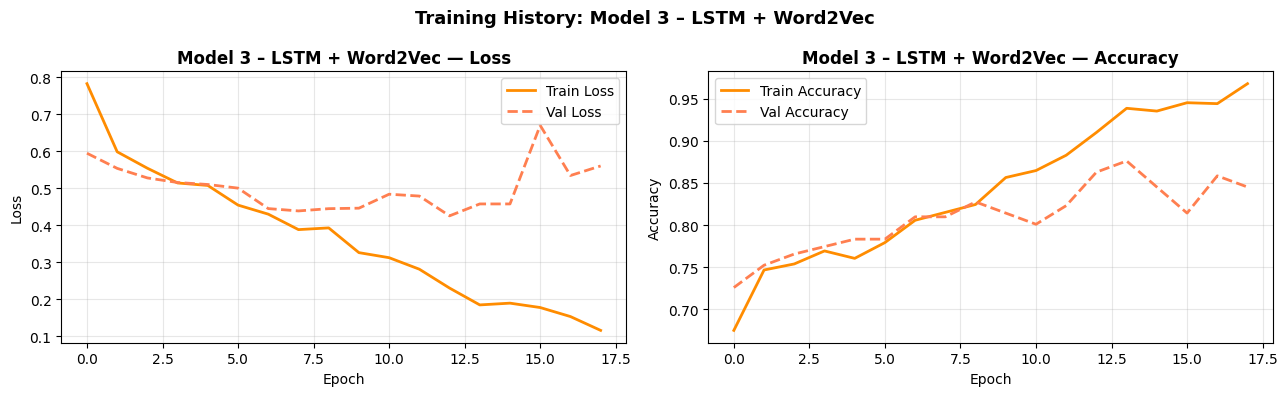

In [20]:
# ── Train Model 3 ────────────────────────────────────────────────
early_stop3 = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)
reduce_lr3 = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-6, verbose=1
)

print("Training Model 3: LSTM + Word2Vec...")
history_w2v = model_w2v.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop3, reduce_lr3],
    verbose=1
)

plot_history(history_w2v, 'Model 3 – LSTM + Word2Vec', color='darkorange')

Section 9: Model comparison and full evaluation


  Model 1 – Simple RNN
  Test Accuracy: 0.7974 (79.74%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.42      0.51        31
     neutral       0.87      0.94      0.90       139
    positive       0.66      0.65      0.65        57

    accuracy                           0.80       227
   macro avg       0.73      0.67      0.69       227
weighted avg       0.79      0.80      0.79       227



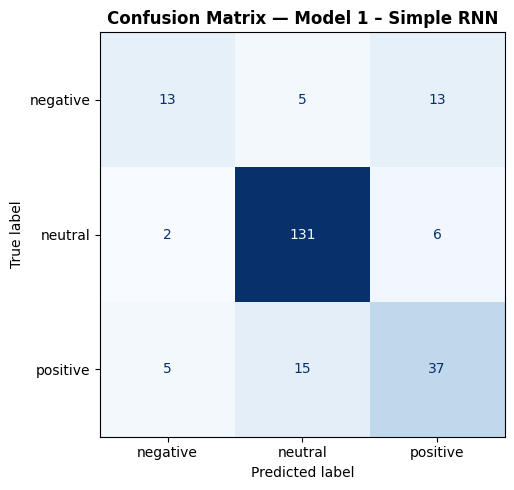


  Model 2 – LSTM
  Test Accuracy: 0.7401 (74.01%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        31
     neutral       0.86      0.93      0.89       139
    positive       0.51      0.68      0.58        57

    accuracy                           0.74       227
   macro avg       0.46      0.54      0.49       227
weighted avg       0.65      0.74      0.69       227



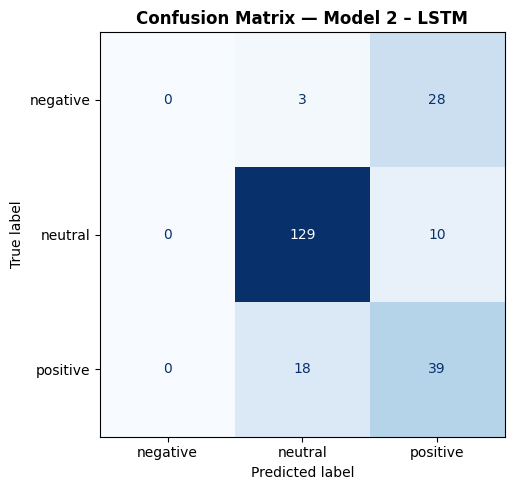


  Model 3 – LSTM + Word2Vec
  Test Accuracy: 0.8546 (85.46%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.61      0.68        31
     neutral       0.90      0.94      0.92       139
    positive       0.79      0.77      0.78        57

    accuracy                           0.85       227
   macro avg       0.81      0.78      0.79       227
weighted avg       0.85      0.85      0.85       227



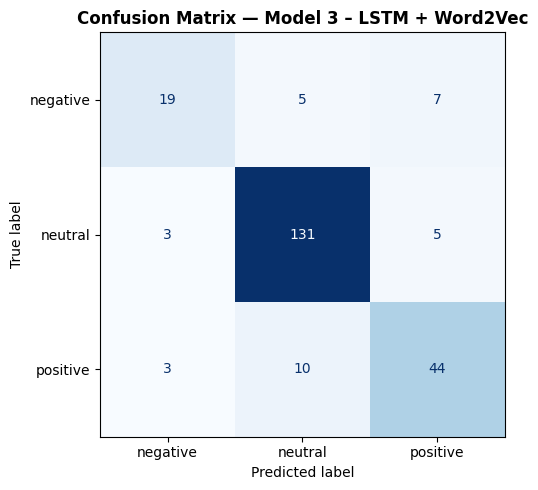

In [21]:
# ── Evaluate All Models on Test Set ─────────────────────────────
def evaluate_model(model, X_test_pad, y_test, y_test_cat, model_name, inv_label_map):
    """
    Returns accuracy and prints confusion matrix + classification report.
    """
    # Get predictions
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)

    print(f"\n{'=' * 55}")
    print(f"  {model_name}")
    print(f"{'=' * 55}")
    print(f"  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=[inv_label_map[i] for i in range(3)]
    ))

    # Confusion Matrix Plot
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[inv_label_map[i] for i in range(3)]
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred


acc_rnn,  y_pred_rnn  = evaluate_model(model_rnn,  X_test_pad, y_test, y_test_cat, 'Model 1 – Simple RNN',       inv_label_map)
acc_lstm, y_pred_lstm = evaluate_model(model_lstm, X_test_pad, y_test, y_test_cat, 'Model 2 – LSTM',             inv_label_map)
acc_w2v,  y_pred_w2v  = evaluate_model(model_w2v,  X_test_pad, y_test, y_test_cat, 'Model 3 – LSTM + Word2Vec',  inv_label_map)

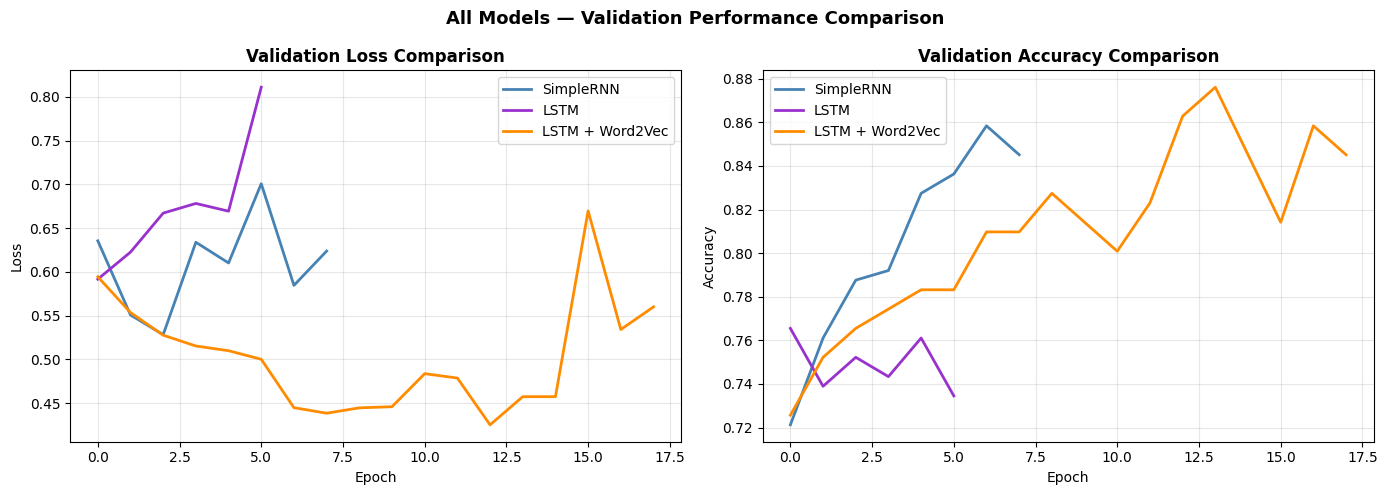

In [22]:
# ── Side-by-Side Training Curve Comparison ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_histories = [
    (history_rnn,  'SimpleRNN',      'steelblue'),
    (history_lstm, 'LSTM',           'darkorchid'),
    (history_w2v,  'LSTM + Word2Vec','darkorange'),
]

for history, name, color in model_histories:
    axes[0].plot(history.history['val_loss'],     label=name, color=color, linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label=name, color=color, linewidth=2)

axes[0].set_title('Validation Loss Comparison',     fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('All Models — Validation Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()


 FINAL MODEL COMPARISON SUMMARY
          Model Test Accuracy          Embedding Type Recurrent Layer
     Simple RNN        79.74% Trainable (random init)       SimpleRNN
           LSTM        74.01% Trainable (random init)         LSTM x2
LSTM + Word2Vec        85.46%   Frozen GloVe (50-dim)         LSTM x2


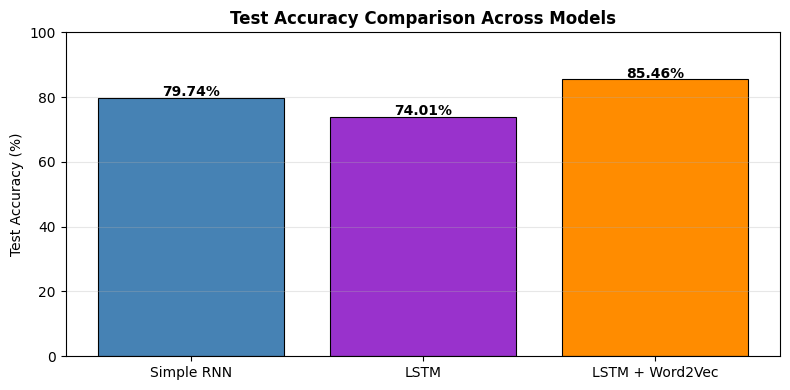

In [23]:
# ── Summary Table ────────────────────────────────────────────────
summary_data = {
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Test Accuracy': [
        f"{acc_rnn*100:.2f}%",
        f"{acc_lstm*100:.2f}%",
        f"{acc_w2v*100:.2f}%"
    ],
    'Embedding Type': [
        'Trainable (random init)',
        'Trainable (random init)',
        'Frozen GloVe (50-dim)'
    ],
    'Recurrent Layer': ['SimpleRNN', 'LSTM x2', 'LSTM x2'],
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 65)
print(" FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)

# Bar chart of accuracy
fig, ax = plt.subplots(figsize=(8, 4))
accs   = [acc_rnn, acc_lstm, acc_w2v]
names  = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
colors_bar = ['steelblue', 'darkorchid', 'darkorange']

bars = ax.bar(names, [a * 100 for a in accs], color=colors_bar, edgecolor='black', linewidth=0.8)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy Comparison Across Models', fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{acc*100:.2f}%",
        ha='center', fontweight='bold'
    )
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Section 10: Error Analysis

In [24]:
# ── Find Misclassified Samples ───────────────────────────────────
# Use best model predictions (assumed Model 3 — update y_pred_best if needed)
y_pred_best = y_pred_w2v   # Change to y_pred_lstm or y_pred_rnn if that model is better
best_model_name = 'LSTM + Word2Vec'

# Build a dataframe of test samples with predictions
test_df = pd.DataFrame({
    'original_text' : X_test,
    'cleaned_text'  : [clean_text(t) for t in X_test],
    'true_label'    : [inv_label_map[i] for i in y_test],
    'pred_label'    : [inv_label_map[i] for i in y_pred_best],
})
test_df['correct'] = test_df['true_label'] == test_df['pred_label']

wrong_df = test_df[~test_df['correct']].reset_index(drop=True)

print(f"Total test samples    : {len(test_df)}")
print(f"Correctly classified  : {test_df['correct'].sum()}")
print(f"Misclassified         : {len(wrong_df)}")
print(f"Error rate            : {len(wrong_df)/len(test_df)*100:.1f}%")

Total test samples    : 227
Correctly classified  : 194
Misclassified         : 33
Error rate            : 14.5%



Misclassified Examples — LSTM + Word2Vec

Example 1:
  Text      : helsinki may finnish company lemminkainen oyj hel lem said today construct office building toolonlahti downtown helsinki without d...
  True Label: NEUTRAL
  Predicted : POSITIVE  ← WRONG
---------------------------------------------------------------------------

Example 2:
  Text      : adp news feb finnish wood product technology supplier raute oyj hel rutav said today net profit decreased eur million usd eur mill...
  True Label: NEGATIVE
  Predicted : POSITIVE  ← WRONG
---------------------------------------------------------------------------

Example 3:
  Text      : net sale eaten weak u dollar
  True Label: NEGATIVE
  Predicted : NEUTRAL  ← WRONG
---------------------------------------------------------------------------

Example 4:
  Text      : net cash flow operating activity negative eur mn compared eur mn corresponding period
  True Label: NEGATIVE
  Predicted : POSITIVE  ← WRONG
-------------------------

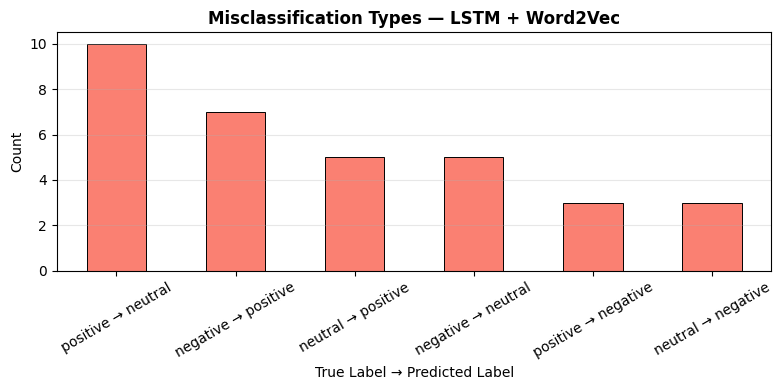

In [25]:
# ── Display 5 Misclassified Examples with Analysis ───────────────
print(f"\nMisclassified Examples — {best_model_name}")
print("=" * 75)

# Show a spread across different error types
sample_errors = wrong_df.sample(min(5, len(wrong_df)), random_state=42)

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    print(f"\nExample {i}:")
    print(f"  Text      : {row['original_text'][:130]}..." if len(row['original_text']) > 130
          else f"  Text      : {row['original_text']}")
    print(f"  True Label: {row['true_label'].upper()}")
    print(f"  Predicted : {row['pred_label'].upper()}  ← WRONG")
    print("-" * 75)

# ── Error Type Distribution ──────────────────────────────────────
wrong_df['error_type'] = wrong_df['true_label'] + ' → ' + wrong_df['pred_label']
error_counts = wrong_df['error_type'].value_counts()

print("\nError Type Breakdown:")
print("-" * 40)
print(error_counts.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
error_counts.plot(kind='bar', ax=ax, color='salmon', edgecolor='black', linewidth=0.7)
ax.set_title(f'Misclassification Types — {best_model_name}', fontweight='bold')
ax.set_xlabel('True Label → Predicted Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Misclassified Examples — LSTM + Word2Vec

Example 1:
  Text      : helsinki may finnish company lemminkainen oyj hel lem said today construct office building toolonlahti downtown helsinki without d...
  True Label: NEUTRAL
  Predicted : POSITIVE  ← WRONG
---------------------------------------------------------------------------

Example 2:
  Text      : adp news feb finnish wood product technology supplier raute oyj hel rutav said today net profit decreased eur million usd eur mill...
  True Label: NEGATIVE
  Predicted : POSITIVE  ← WRONG
---------------------------------------------------------------------------

Example 3:
  Text      : net sale eaten weak u dollar
  True Label: NEGATIVE
  Predicted : NEUTRAL  ← WRONG
---------------------------------------------------------------------------

Example 4:
  Text      : net cash flow operating activity negative eur mn compared eur mn corresponding period
  True Label: NEGATIVE
  Predicted : POSITIVE  ← WRONG
-------------------------

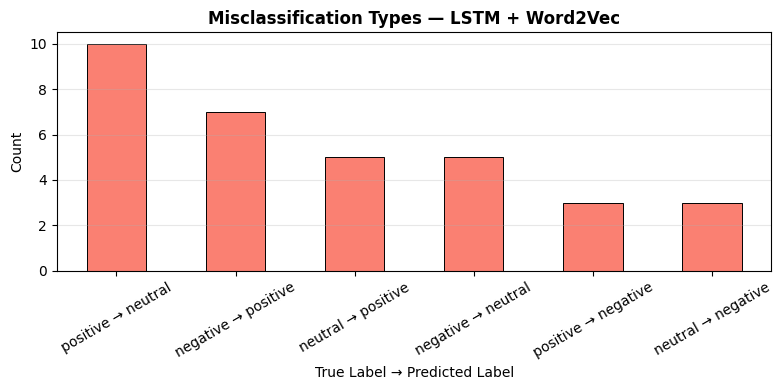

In [26]:
# ── Display 5 Misclassified Examples with Analysis ───────────────
print(f"\nMisclassified Examples — {best_model_name}")
print("=" * 75)

# Show a spread across different error types
sample_errors = wrong_df.sample(min(5, len(wrong_df)), random_state=42)

for i, (_, row) in enumerate(sample_errors.iterrows(), 1):
    print(f"\nExample {i}:")
    print(f"  Text      : {row['original_text'][:130]}..." if len(row['original_text']) > 130
          else f"  Text      : {row['original_text']}")
    print(f"  True Label: {row['true_label'].upper()}")
    print(f"  Predicted : {row['pred_label'].upper()}  ← WRONG")
    print("-" * 75)

# ── Error Type Distribution ──────────────────────────────────────
wrong_df['error_type'] = wrong_df['true_label'] + ' → ' + wrong_df['pred_label']
error_counts = wrong_df['error_type'].value_counts()

print("\nError Type Breakdown:")
print("-" * 40)
print(error_counts.to_string())

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
error_counts.plot(kind='bar', ax=ax, color='salmon', edgecolor='black', linewidth=0.7)
ax.set_title(f'Misclassification Types — {best_model_name}', fontweight='bold')
ax.set_xlabel('True Label → Predicted Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── Written Error Analysis ───────────────────────────────────────
print("""
ERROR ANALYSIS SUMMARY
======================

1. Neutral ↔ Positive Confusion:
   Many financial sentences report factual growth figures without strong
   sentiment cues. For example, a sentence stating "net sales increased
   by 5%" reads as factual (neutral) but can also be interpreted as
   positive. The model struggles with this boundary.

2. Neutral ↔ Negative Confusion:
   Similarly, cautious or risk-mentioning sentences (e.g., "the company
   does not plan to expand") are sometimes classified as negative even
   when they are factually neutral statements.

3. Minority Class (Negative) Errors:
   The dataset has only 13.4% negative samples. The model sees fewer
   negative examples during training, which leads to lower recall on
   negative class. This is a direct consequence of class imbalance.

4. Complex Financial Language:
   Financial text often uses domain-specific vocabulary (e.g., EBITDA,
   pre-tax profit, operating margin) that may not be well-represented in
   general-purpose GloVe embeddings trained on Wikipedia/news data.

POTENTIAL IMPROVEMENTS:
  - Use class weights or oversampling (SMOTE) to handle class imbalance.
  - Use domain-specific embeddings (e.g., FinBERT, financial word2vec).
  - Apply Bidirectional LSTM to capture context from both directions.
  - Add attention mechanism to focus on sentiment-bearing words.
""")


ERROR ANALYSIS SUMMARY

1. Neutral ↔ Positive Confusion:
   Many financial sentences report factual growth figures without strong
   sentiment cues. For example, a sentence stating "net sales increased
   by 5%" reads as factual (neutral) but can also be interpreted as
   positive. The model struggles with this boundary.

2. Neutral ↔ Negative Confusion:
   Similarly, cautious or risk-mentioning sentences (e.g., "the company
   does not plan to expand") are sometimes classified as negative even
   when they are factually neutral statements.

3. Minority Class (Negative) Errors:
   The dataset has only 13.4% negative samples. The model sees fewer
   negative examples during training, which leads to lower recall on
   negative class. This is a direct consequence of class imbalance.

4. Complex Financial Language:
   Financial text often uses domain-specific vocabulary (e.g., EBITDA,
   pre-tax profit, operating margin) that may not be well-represented in
   general-purpose GloVe embeddi

In [28]:
# ── Save Models ──────────────────────────────────────────────────
model_rnn.save('model_1_simple_rnn.h5')
model_lstm.save('model_2_lstm.h5')
model_w2v.save('model_3_lstm_w2v.h5')

print("✅ All three models saved successfully!")
print("   model_1_simple_rnn.h5")
print("   model_2_lstm.h5")
print("   model_3_lstm_w2v.h5")

✅ All three models saved successfully!
   model_1_simple_rnn.h5
   model_2_lstm.h5
   model_3_lstm_w2v.h5


End of Part III - NLP Task